# Nonlinear Regression

### Generate nonlinear data

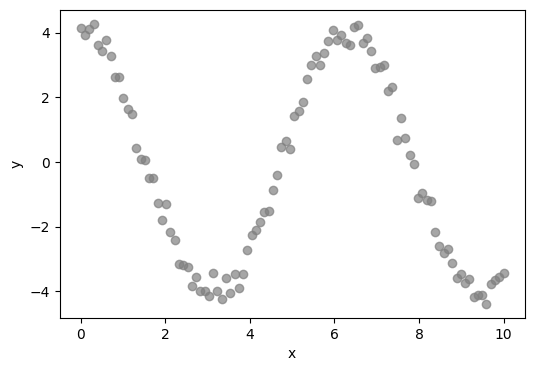

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate nonlinear data
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 4 * np.cos(X).ravel() + np.random.normal(0, 0.3, 100)

# Visualize data
plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='gray', alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.show()


### Fit a Linear Regression Model

1- Call a linear regression model.

2- Train the model on the previous data.

3- Generate predictions.

4- Visualize results (data points and LR predictions).

5- Compute R² metric.

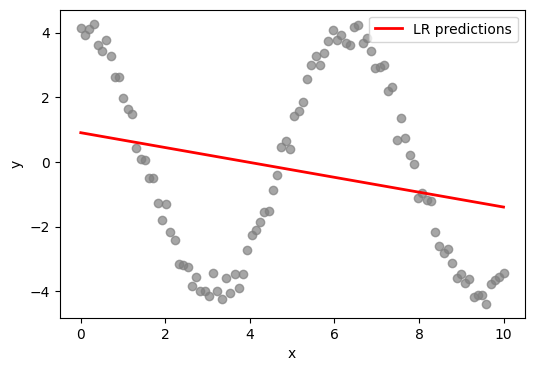

Linear R²: 0.0515309154680581


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


lin = LinearRegression()
lin.fit(X, y)
y_pred_lin = lin.predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='gray', alpha=0.7)
plt.plot(X, y_pred_lin, color='red', linewidth=2, label='LR predictions')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()
print("Linear R²:", r2_score(y, y_pred_lin))



### Fit Polynomial Regression Models

In [3]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)



1- Call a LR model.

2- Train it on the new data.

3- Generate predictions.

4- Visualize results (data points and LR predictions).

5- Compute R² metric.

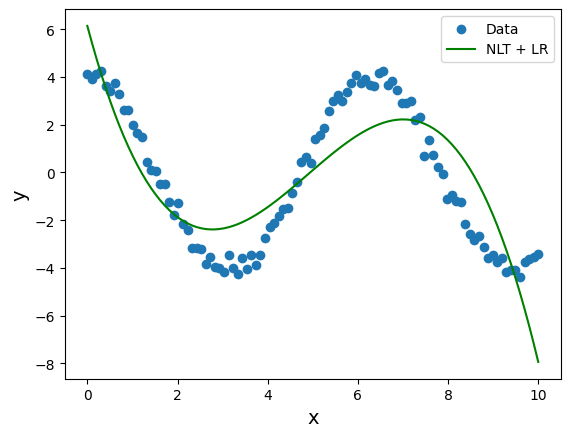

R² after NLT: 0.704850270191248


In [4]:
model_poly = LinearRegression()
model_poly.fit(X_poly, y)
y_pred_poly = model_poly.predict(X_poly)

plt.scatter(X, y, label='Data')
plt.plot(X, y_pred_poly, color='green', label='NLT + LR')
plt.legend()
# plt.title('Solution 1: Polynomial Features + Linear Regression')
plt.xlabel("x", fontsize=14)
plt.ylabel("y", fontsize=14)
plt.show()

print("R² after NLT:", r2_score(y, y_pred_poly))




1- Use NLTs with the following degrees: 3, 4, and 5.

2- At each time train a LR model.

3- Generate predictions.

4- Visualize results on the same graph: data points and LR predictions for the three degrees.

5- Compute R² metric for each case.



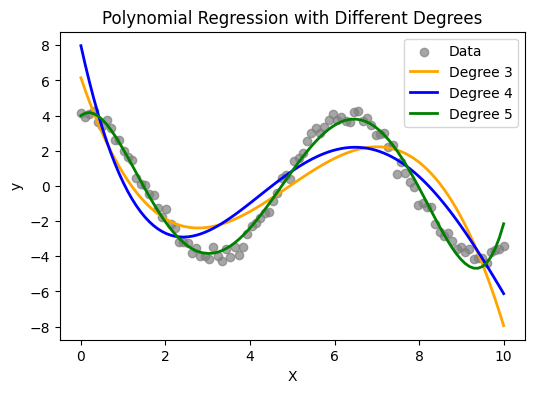

R2 values:  [0.704850270191248, 0.7567562968825015, 0.9788011186241946]


In [5]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [3, 4, 5]
colors = ['orange', 'blue', 'green']
r2 = []
plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='gray', alpha=0.7, label='Data')

for degree, color in zip(degrees, colors):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    lin_poly = LinearRegression()
    lin_poly.fit(X_poly, y)
    y_pred_poly = lin_poly.predict(X_poly)
    plt.plot(X, y_pred_poly, color=color, linewidth=2, label=f"Degree {degree}")
    r2.append(r2_score(y, y_pred_poly))

plt.legend()
plt.title("Polynomial Regression with Different Degrees")
plt.xlabel("X")
plt.ylabel("y")
plt.show()
print('R2 values: ', r2)
